In [65]:
%load_ext autoreload
%autoreload 2

from dqn_agent import Agent

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [66]:
import gymnasium as gym
from collections import deque
import numpy as np
import torch
import matplotlib.pyplot as plt
env = gym.make("LunarLander-v3")
# (x,y, x_speed, y_speed, angle, angle_speed, касание левой опорой, касание правой опорой
state_size = env.observation_space.shape[0]  # Извлекаем целое число из кортежа (8,)
action_size = env.action_space.n

agent = Agent(state_size, action_size, seed=1)

In [67]:
agent

Эпизод 100	Средняя награда: -161.09эпизодов): -161.09
Эпизод 200	Средняя награда: -67.88 эпизодов): -67.882

🎥 Запуск демонстрации для эпизода 200...
0.4850700000003504
✅ Демонстрация завершена. Продолжаем обучение...

Эпизод 300	Средняя награда: -62.88 эпизодов): -62.88
Эпизод 400	Средняя награда: -22.88 эпизодов): -22.88

🎥 Запуск демонстрации для эпизода 400...
0.979079999998185
✅ Демонстрация завершена. Продолжаем обучение...

Эпизод 500	Средняя награда: -8.740 эпизодов): -8.743
Эпизод 600	Средняя награда: 22.300 эпизодов): 22.30

🎥 Запуск демонстрации для эпизода 600...
1.0
✅ Демонстрация завершена. Продолжаем обучение...

Эпизод 700	Средняя награда: 36.570 эпизодов): 36.57
Эпизод 800	Средняя награда: 38.390 эпизодов): 38.39

🎥 Запуск демонстрации для эпизода 800...
1.0
✅ Демонстрация завершена. Продолжаем обучение...

Эпизод 900	Средняя награда: 75.170 эпизодов): 75.17
Эпизод 1000	Средняя награда: 257.90 эпизодов): 257.90

🎥 Запуск демонстрации для эпизода 1000...
1.0
✅ Демонстра

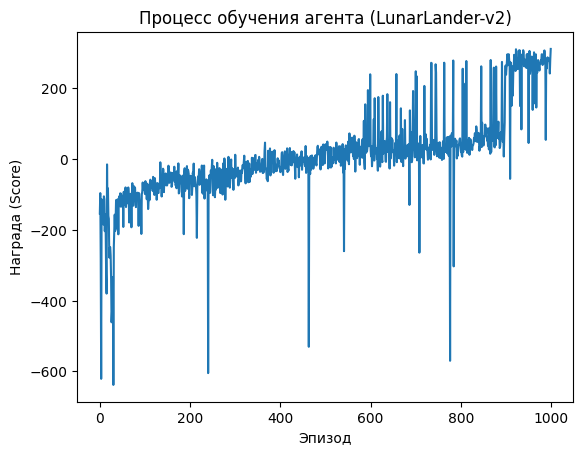

: 

In [ ]:
import time
def train(episodes=1000, max_t=1000):
    scores=[]
    scores_window = deque(maxlen=100)

    for episode in range(1, episodes+1):
        state, info = env.reset()
        score = 0

        for t in range(max_t):
            action = agent.act(state) # predict модели
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated # завершен или истек по времени
            agent.step(state, action, reward, next_state, done)

            state=next_state
            score+=reward
            if done: break
        
        scores_window.append(score)
        scores.append(score)
        


        print(f'\rЭпизод {episode}\tСредняя награда (за 100 эпизодов): {np.mean(scores_window):.2f}', end="")
        
        if episode % 100 == 0:
            print(f'\rЭпизод {episode}\tСредняя награда: {np.mean(scores_window):.2f}')
        if np.mean(scores_window) > 200:
            torch.save(agent.qnetwork_local.state_dict(), 'best_model.pth')
        if episode==episodes:
            torch.save(agent.qnetwork_local.state_dict(), 'final_network.pth')
        # --- НОВЫЙ БЛОК: ДЕМОНСТРАЦИЯ КАЖДЫЕ 200 ЭПИЗОДОВ ---
        if episode % 200 == 0:
            print(f"\n🎥 Запуск демонстрации для эпизода {episode}...")
            # Создаем среду специально для отрисовки
            env_render = gym.make('LunarLander-v3', render_mode='human')
            state_render, _ = env_render.reset()
            done_render = False
            
            while not done_render:
                action_render = agent.act(state_render, is_eval=True) 
                
                next_state_render, _, terminated_render, truncated_render, _ = env_render.step(action_render)
                state_render = next_state_render
                done_render = terminated_render or truncated_render
                
            env_render.close() 
            print(agent.memory.beta)
            print("✅ Демонстрация завершена. Продолжаем обучение...\n")
    
    return scores
        
start=time.time()
scores = train()
print(f'Train time: {time.time() - start}')
# Строим график процесса обучения
fig = plt.figure()
ax = fig.add_subplot(111)
plt.plot(np.arange(len(scores)), scores)
plt.ylabel('Награда (Score)')
plt.xlabel('Эпизод')
plt.title('Процесс обучения агента (LunarLander-v2)')
plt.show()

env.close()